In [240]:
# import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind


In [137]:
df = pd.read_csv("zara_transaction_data.csv")

In [141]:
#df.head()
#df.tail()

In [138]:
df

,Product_Id,Date,Product_Position,Product_Category,Sales_Volume,Brand,Name,Price,Currency,Terms,Section,Product_Variant
0,GLXT0Y2HED,19/08/2024,aisle,clothing,1,Zara,Faux Leather Jacket,24.99,USD,jackets,woman,A
1,T8JAGW2ZT0,19/06/2024,aisle,clothing,3,Zara,Faux Leather Jacket,24.99,USD,jackets,woman,A
2,F24IJY31BS,17/07/2024,aisle,clothing,3,Zara,Faux Leather Jacket,24.99,USD,jackets,woman,A
3,AUQQS4AR0Q,07/06/2024,aisle,clothing,2,Zara,Faux Leather Jacket,24.99,USD,jackets,woman,A
4,1EG5Y64MG5,16/08/2024,aisle,clothing,2,Zara,Faux Leather Jacket,24.99,USD,jackets,woman,A
...,...,...,...,...,...,...,...,...,...,...,...,...
995,ZIR6ZKKHIO,30/07/2024,aisle,clothing,3,Zara,Faux Leather Jacket,35.99,USD,jackets,woman,B
996,AHVF6RUG3S,29/07/2024,aisle,clothing,2,Zara,Faux Leather Jacket,35.99,USD,jackets,woman,B
997,A0PKMR9IYI,28/06/2024,aisle,clothing,2,Zara,Faux Leather Jacket,35.99,USD,jackets,woman,B
998,IRT4WSP71M,20/06/2024,aisle,clothing,2,Zara,Faux Leather Jacket,35.99,USD,jackets,woman,B


In [ ]:
# Checking for na and null values in data

In [142]:
print(df.isna().sum())

Product_Id          0
Date                0
Product_Position    0
Product_Category    0
Sales_Volume        0
Brand               0
Name                0
Price               0
Currency            0
Terms               0
Section             0
Product_Variant     0
dtype: int64


In [143]:
print(df.isnull().sum())

Product_Id          0
Date                0
Product_Position    0
Product_Category    0
Sales_Volume        0
Brand               0
Name                0
Price               0
Currency            0
Terms               0
Section             0
Product_Variant     0
dtype: int64


In [12]:
# Checking table stats

In [13]:
df.describe()

,Sales_Volume,Price
count,1000.000000,1000.000000
mean,1.972000,30.490000
std,0.813559,5.502752
min,1.000000,24.990000
25%,1.000000,24.990000
50%,2.000000,30.490000
75%,3.000000,35.990000
max,3.000000,35.990000


In [14]:
# Checking columns

In [145]:
df["Sales_Volume"].describe()

count    1000.000000
mean        1.972000
std         0.813559
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         3.000000
Name: Sales_Volume, dtype: float64

In [146]:
df["Product_Variant"].describe()

count     1000
unique       2
top          B
freq       500
Name: Product_Variant, dtype: object

In [171]:
df["Product_Variant"].unique()

array(['A', 'B'], dtype=object)

In [18]:
# Data Analysis

In [232]:
# Computing "Profit", finding mean profit per customer in each price group, and calculating p-value

cost = 15   # Assuming cost to be 15
df["Profit"] = df["Sales_Volume"] * (df["Price"] - cost)   # Computing "Profit"

# Splitting into A and B groups
Profit_A = df[df["Product_Variant"] == "A"]["Profit"]
Profit_B = df[df["Product_Variant"] == "B"]["Profit"]

t_stat, p_value = ttest_ind(Profit_A, Profit_B, equal_var=False)

In [234]:
print("mean profit per customer in price group A:", Profit_A.mean())
print("mean profit per customer in price group B:", Profit_B.mean())
print(f"p_value is: {p_value:.120f}")

mean profit per customer in price group A: 19.52046
mean profit per customer in price group B: 41.77010000000001
p_value is: 0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000049780620349749


In [242]:
print("p-value is:", p_value)

p-value is: 4.978062034974917e-107


In [241]:
if p_value < 0.05:
    print("Statistical significance")
else:
    print("No statistical signifance")

Statistical significance


In [ ]:
# Exploratory Data Analysis

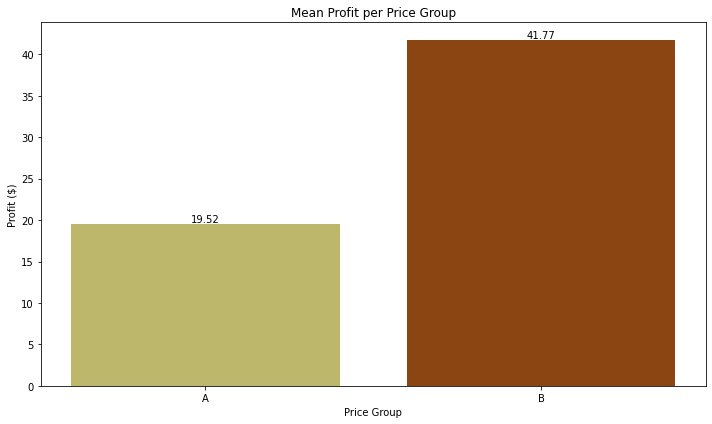

In [ ]:
# mean profit comparison between the two prices

mean_A = Profit_A.mean()
mean_B = Profit_B.mean()

mean_values = [mean_A, mean_B]
price_groups = ["A", "B"]

plt.figure(figsize=(10,6), facecolor="white")
mean_profit = plt.bar(price_groups, mean_values, color=['darkkhaki', 'saddlebrown'])
plt.xlabel("Price Group")
plt.ylabel("Profit ($)")
plt.title("Mean Profit per Price Group")

for bar in mean_profit:
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2

    plt.text(x, height, f"{height:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

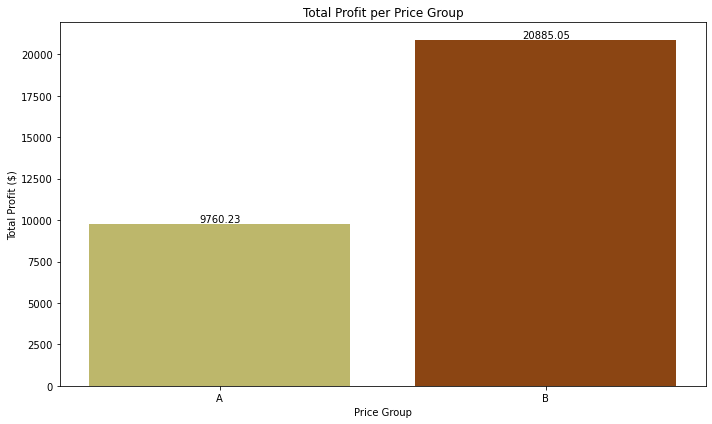

In [ ]:
# Total profit comparison between the two prices

Sum_Profit_A = Profit_A.sum()
Sum_Profit_B = Profit_B.sum()

total_profit_values = [Sum_Profit_A, Sum_Profit_B]
price_groups_tp = ["A", "B"]

plt.figure(figsize=(10,6), facecolor="white")
total_p = plt.bar(price_groups_tp, total_profit_values, color = ['darkkhaki', 'saddlebrown'])
plt.xlabel('Price Group')
plt.ylabel('Total Profit ($)')
plt.title('Total Profit per Price Group')
#plt.gca().spines['right'].set_visible(False)
#plt.gca().spines['top'].set_visible(False)

for bar in total_p:
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2

    plt.text(x, height, f"{height:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

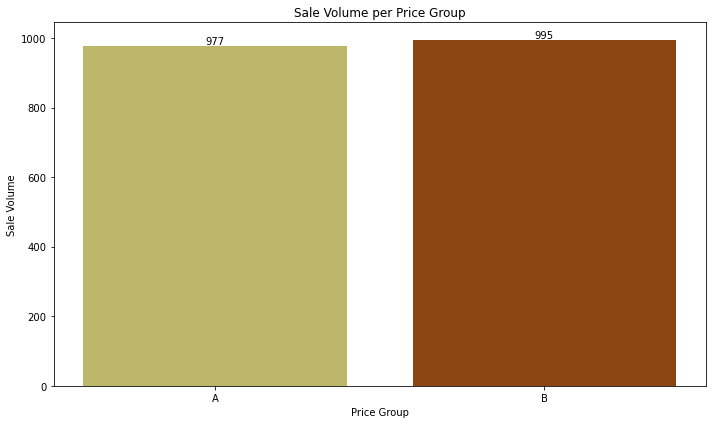

In [238]:
# Sales Volume comparison between the two price groups

Sales_Groups = df.groupby("Product_Variant")["Sales_Volume"].sum()
#Sales_Groups = Sales_Groups.rename({'A': '$24.99', 'B':'35.99'})

plt.figure(figsize=(10,6))
sales_plot = plt.bar(Sales_Groups.index, Sales_Groups.values, color=['darkkhaki', 'saddlebrown'])
plt.xlabel('Price Group')
plt.ylabel('Sale Volume')
plt.title('Sale Volume per Price Group')

for bar in sales_plot:
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2

    plt.text(x, height, f"{height:.0f}", va="bottom", ha="center")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Time Series of Profit per Price Group')

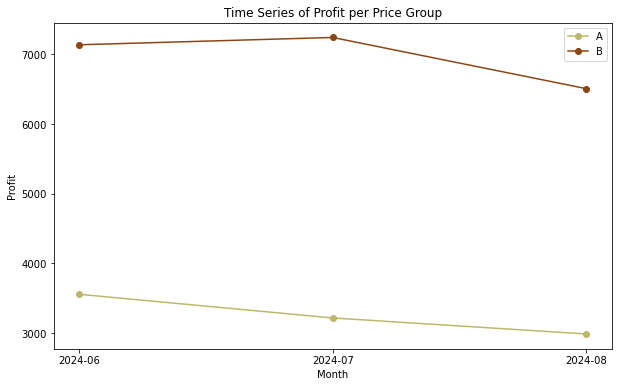

In [237]:
# Time Series of total profit per price group

df['Date'] = pd.to_datetime(df['Date'], format = '%d/%m/%Y')
df['Year_Month'] = df['Date'].dt.to_period('M').astype(str)

monthly_profit = (df.groupby(["Year_Month", "Product_Variant"])["Profit"].sum().reset_index())

ts_data = monthly_profit.pivot(index="Year_Month", columns="Product_Variant", values="Profit")

plt.figure(figsize=(10,6), facecolor="white")
plt.plot(ts_data.index, ts_data["A"], marker="o", label = "A", color = "darkkhaki")
plt.plot(ts_data.index, ts_data["B"], marker="o", label = "B", color = "saddlebrown")
plt.legend()
plt.xlabel("Month")
plt.ylabel("Profit")
plt.title("Time Series of Profit per Price Group")